## Quinta etapa

Em quinta_etapa.ipynb, utilizaremos dos registros que filtramos (ou não) em quarta_etapa.ipynb, e faremos a filtragem dos taxonomistas. Os taxonomistas são as pessoas responsáveis pela identificação taxonômica dos registros de plantas que utilizamos no nosso acervo, e é de suma importância que essa identificação seja feita da maneira correta, considerando que nossos rótulos serão utilizados para o treino de uma inteligência artificial e se estiverem errados, ela também aprenderá esses erros.

Assim sendo, escolheremos os taxonomistas com maior grau de confiança baseado na quantia de identificações realizadas por eles, considerando que quanto mais identificações um taxonomista tem em uma dada família, menores são as chances dela estar incorreta.

Seguindo a mesma convenção da etapa anterior, o nome do novo campo será identifiedby_att, pois o campo original é identifiedby.

Caso não deseje realizar essa filtragem, siga utilizando o campo identifiedby ao invés de identifiedby_att nas próximas filtragens.

In [1]:
from bibliotecas import *

specieslink, db_config = configurar()

In [2]:
def identificadores(table, db_config):
    conn = mysql_conn.connect(**db_config)
    cursor = conn.cursor()

    requisito = "country_att"
    requisito2 = "stateprovince_att"
    requisito3 = "barcode_att"
    coluna = "identifiedby"

    sql = f"""SELECT {coluna} FROM {table} WHERE {coluna} IS NOT NULL AND {requisito} IS NOT NULL AND {requisito2} IS NOT NULL AND {requisito3} IS NOT NULL GROUP BY {coluna}"""

    cursor.execute(sql)
    autores = [row[0] for row in cursor.fetchall()]

    cursor.close()
    conn.close()  

    return autores

In [3]:
ranking = int(input("quantos autores mais frequentes você quer exibir? ").strip())
similar = int(input("nível de similaridade fuzzy (0-100%): ").strip())
table = "registros_biodiversidade"
txt = input("caminho .txt para salvar o resultado dos agrupamentos: ").strip()

if not ranking:
    ranking = 5
if similar < 0 or similar > 100:
    similar = 60
if not txt:
    txt = "deduplicacao.txt"

autores = identificadores(table, db_config)

df = pd.DataFrame({"identifiedby": autores})

csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False)
csv_buffer.seek(0)

processar(csv_buffer, ranking, similar, txt)



top 10 taxonomistas mais frequentes:

1. H.C.H.Silva -> 38 ocorrência(s)
2. L.F. Souza -> 37 ocorrência(s)
3. P. Fiaschi. -> 26 ocorrência(s)
4. A.Lourteig -> 19 ocorrência(s)
5. Santos, A.C.B. -> 18 ocorrência(s)
6. A. Conceicão -> 18 ocorrência(s)
7. S.Z. Cordeiro -> 17 ocorrência(s)
8. Lima, I.L.P. -> 17 ocorrência(s)
9. Oliveira, M. -> 15 ocorrência(s)
10. Abreu, MC -> 15 ocorrência(s)


Usei 10 identificadores, e 80% de acurácia. Fiz um mapeamento assim como no estado:

In [7]:
IDENTIFICADORES_MAP = {
    "H.C.H.Silva": [
        "H.C.H.Silva"
        ,"F.F.S. Silva"
        ,"Silva, A."
        ,"Da Silva, D.R."
        ,"Silva, R.A."
        ,"Silva, AN"
        ,"Silva, M.B.C."
        ,"M.S. Silveira"
        ,"Silva, FO"
        ,"R.A. Silva"
        ,"Silva, MG da"
        ,"Silva, MA"
        ,"Silva, JS"
        ,"Silva, M.R."
        ,"Silva, A.C.B."
        ,"F. R.da Silveira"
        ,"Silva, KF"
        ,"A. A. Silva"
        ,"H.L. Silva"
        ,"R.H.Silva"
        ,"M.L.M. Silva"
        ,"A.C.C.P. Silva"
        ,"A.C.C. Silva"
        ,"A. M. Silveira"
        ,"Silva, D.R."
        ,"Silva, M.A.T."
        ,"Silva, AF"
        ,"Silva, JM"
        ,"Silva, K.F."
        ,"Silva, ACC"
        ,"M.F. Silva"
        ,"M.J. Silva"
        ,"Silva, F"
        ,"M.G. Silva"
        ,"Silva, A.C.C."
        ,"Silva, A.A."
        ,"Silva, CFS"
        ,"Silva, MF da"
    ],
    "L.F. Souza": [
      "L.F. Souza"
      ,"Sousa, DS"
      ,"Souza, IM"
      ,"F. O. Souza"
      ,"Souza, J.M."
      ,"Souza, JM"
      ,"Sousa, R.M.S."
      ,"J.M.Souza"
      ,"Souza, JM de"
      ,"Souza, RS"
      ,"Souza, L.C."
      ,"E.B.Souza"
      ,"F.O. Souza"
      ,"D.P. Souza"
      ,"Souza, JRP"
      ,"Souza, E.B."
      ,"Souza, FO"
      ,"Souza, J.P."
      ,"Souza, MC de"
      ,"Souza, D.P."
      ,"J.M. Souza"
      ,"Souza, R.S."
      ,"Souza, JP"
      ,"Souza, D"
      ,"Souza, I."
      ,"W.G. Delfino & J.M. Souza"
      ,"Conceição, AA; Souza, JM de"
      ,"Delfino, WG; Souza, JM de"
      ,"Souza, E.B.; Araújo, F.F."
      ,"Souza, E.B.; Nepomuceno, F.A.A."
      ,"Delfino, W.G; Souza, J.M."
      ,"Conceição, AA; Fiaschi, P; Souza, JM de"
      ,"Conceição, AA; Souza, JM"
      ,"E.B.Souza & F.F.Araújo"
      ,"W.G.Delfino & J.M.Souza"
      ,"A.A.Conceição & J.M.Souza"
      ,"J.B.S.Nascimento & E.B.Souza"
    ],
    "P. Fiaschi.": [
      "P. Fiaschi."
      ,"A.Fiaschi"
      ,"Fiasch"
      ,"Fiashi,P."
      ,"Fiaschi, P"
      ,"Fiaschi,P."
      ,"P.Finschi"
      ,"P.Fiachi"
      ,"Fiaschi , P."
      ,"Fischi, P"
      ,"Fiasch, P."
      ,"Fiaschi, P."
      ,"P. Fiasch"
      ,"Fiashi, P."
      ,"Faschi, P"
      ,"P. Fiaschi"
      ,"P.Fiaschi"
      ,"Proença, CEB & Fiaschi, P"
      ,"Fiaschi, P; Santiago, DS"
      ,"Fiaschi, P.; Cabral, F.S."
      ,"Fiaschi, P.; Costa, I.G."
      ,"Vasques, J.; Fiaschi, P."
      ,"Campestrini, S.; Fiaschi, P."
      ,"Conceição, AA; Fiaschi, P; Souza, JM de"
      ,"P. Fiaschi & B. Schindler"
      ,"Batalha, MA; Faschi, P"
    ],
    "A.Lourteig": [
      "A.Lourteig"
      ,"A. Louteig"
      ,"A. Lourteig (P)"
      ,"A. Lourteig (P)"
      ,"A, Lourteig"
      ,"Lourteig, L"
      ,"A.Lourteig."
      ,"Laurteig, A."
      ,"L. Lourteig"
      ,"A. Lourbeig"
      ,"A. Lourteig, 12/76"
      ,"Lourteig, A."
      ,"A. Loureteig"
      ,"Laurteig"
      ,"A. Lourteig"
      ,"A. Lourteig, 12."
      ,"Lourteig"
      ,"Lourteig, A"
      ,"Louerteig, A."
      ,"Lourteiga, A."
    ],
    "Santos, A.C.B.": [
      "Santos, A.C.B."
      ,"Santos, J.L."
      ,"E.D. Santos"
      ,"Santos, J.P."
      ,"Santos, L.B."
      ,"Santos, L.C."
      ,"Santos, LA"
      ,"A.C.B. Santos"
      ,"Santos, JR"
      ,"Santos, NA"
      ,"Santos, E.P."
      ,"Santos, L.R."
      ,"Santos, SP"
      ,"Santos, LB"
      ,"Santos, F.D."
      ,"L. C. Santos"
      ,"L.C. Santos"
      ,"Santos, E.D."
    ],
    "A. Conceicão": [
      "A. Conceicão"
      ,"Conceição, A"
      ,"Conceição, A.A."
      ,"Conceição, AS"
      ,"A.S.Conceição"
      ,"A.A.Conceição"
      ,"A.A. Conceição"
      ,"Conceição, A."
      ,"Conceição, AA"
      ,"A. A. Conceição"
      ,"Conceição, AA; Neves, SPS"
      ,"Conceição, AA; Souza, JM de"
      ,"Giulietti, AM; Conceição, AA"
      ,"Conceição, A.A.; Neves, S.P.S."
      ,"Conceição, AA; Fiaschi, P; Souza, JM de"
      ,"Conceição, AA; Souza, JM"
      ,"A.A.Conceição & W.G.Delfino"
      ,"A.A.Conceição & J.M.Souza"
    ],
    "S.Z. Cordeiro": [
      "S.Z. Cordeiro"
      ,"Cordeiro, J."
      ,"Cordeiro, I"
      ,"Cordeiro, MR"
      ,"Cordeiro, J"
      ,"J. Cordeiro"
      ,"J. Cordeiro & E. Barbosa"
      ,"E. Barbosa & J. Cordeiro"
      ,"Cordeiro, J.; Martin, V.C."
      ,"Cordeiro, J.; Barbosa, E."
      ,"Cordeiro, J.; Barboza, E."
      ,"Cordeiro, J; Barboza, E"
      ,"Cordeiro, J; Cruz, JM"
      ,"Cordeiro, J.; Santos, E.L. dos"
      ,"E. Barboza & J. Cordeiro"
      ,"J. Cordeiro & E. Barboza"
      ,"J. Cordeiro & F. Marinero"
    ],
    "Lima, I.L.P.": [
      "Lima, I.L.P."
      ,"Lima, EA"
      ,"Lima, A.D."
      ,"Lima, L.C.P."
      ,"L.C.P. Lima"
      ,"Lima, A.F."
      ,"Lima, JLC"
      ,"Lima, D.F.S."
      ,"Lima, J.C.M."
      ,"Lima, E.A."
      ,"Lima, LCP"
      ,"Lima, A.P.F. de"
      ,"Lima, J."
      ,"Lima, D.F."
      ,"Lima, G.P."
      ,"Lima, J.L.C."
      ,"H.C. Lima"
    ],
    "Oliveira, M.": [
      "Oliveira, M."
      ,"Oliveira, F. C. S."
      ,"Oliveira, D.G."
      ,"Oliveira, M.D."
      ,"Oliveira, DG"
      ,"Oliveira, JCL de"
      ,"Oliveira, M.A."
      ,"Oliveira, C.F."
      ,"Oliveira, DA"
      ,"Oliveira, DN de"
      ,"D.G. Oliveira"
      ,"A.C.P. Oliveira"
      ,"Oliveira, AA"
      ,"Oliveira, M"
      ,"Araújo, L.S.; Lemos, J.R.; Andrade, I.M.; Oliveira, M.A."
    ],
    "Abreu, MC": [
      "Abreu, MC"
      ,"C. Abreu"
      ,"Abreu, M.C. de"
      ,"Abreu, C"
      ,"M.C. de Abreu"
      ,"M. C. Abreu"
      ,"M.C. Abreu"
      ,"Abreu, M,C."
      ,"Abreu, M C"
      ,"Abreu, M.C."
      ,"Abreu, LG"
      ,"Abreu. M.C."
      ,"Abreu, MC de"
      ,"Borges, K.M.L.; Abreu, M.C."
      ,"Cano, O.; Abreu, M.C."
    ],
}


In [8]:
def filtragem_pipeline(campo_input,table,filter_field,filter_values,update_value,db_config):
    if not campo_input:
        print("campo_input não informado")
        return

    conn = mysql_conn.connect(**db_config)
    cursor = conn.cursor()

    try:
        sql = f"ALTER TABLE {table} ADD COLUMN {campo_input} TEXT"
        cursor.execute(sql)
        conn.commit()
        print(f"campo '{campo_input}' criado com sucesso na tabela '{table}'")
    except Exception:
        pass
    finally:
        cursor.close()
        conn.close()

    for valor in filter_values: # versão que recebe um unico valor ao inves de receber varios por terminal
        specieslink.update_records(
            filters={filter_field: valor},
            update_values={campo_input: update_value},
            db_config=db_config,
            table=table
        )


In [9]:
campo_input = input("informe o nome que voce deseja que o novo campo tenha (não crie o campo manualmente quando executando pelo pipeline!)").strip()
table = "registros_biodiversidade"

for estado_padrao, variantes in IDENTIFICADORES_MAP.items():
    for variante in variantes:
        update_input = f"{campo_input}={estado_padrao}"
        filters_input = f"identifiedby={variante}"

        print(f"executando specieslink.update_records(filters={filters_input}, update_values={update_input}, table={table})...\n")


    filtragem_pipeline(
        campo_input=campo_input,
        table=table,
        filter_field="identifiedby",
        filter_values=variantes,
        update_value=estado_padrao,
        db_config=db_config
    )


executando specieslink.update_records(filters=identifiedby=H.C.H.Silva, update_values=identifiedby_att=H.C.H.Silva, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=F.F.S. Silva, update_values=identifiedby_att=H.C.H.Silva, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Silva, A., update_values=identifiedby_att=H.C.H.Silva, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Da Silva, D.R., update_values=identifiedby_att=H.C.H.Silva, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Silva, R.A., update_values=identifiedby_att=H.C.H.Silva, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Silva, AN, update_values=identifiedby_att=H.C.H.Silva, table=registros_biodiversidade)...

executando specieslink.update_records(filters=identifiedby=Silva, M.B.C., update_values=

In [10]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS com_country,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL) AS com_country_e_state,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL) as com_country_state_e_barcode,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL AND identifiedby_att IS NOT NULL) as com_country_state_barcode_e_identificador   
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_country, registros_country_state, registros_country_state_barcode, registros_country_state_barcode_e_identificador = cursor.fetchone()

cursor.close()
conn.close()

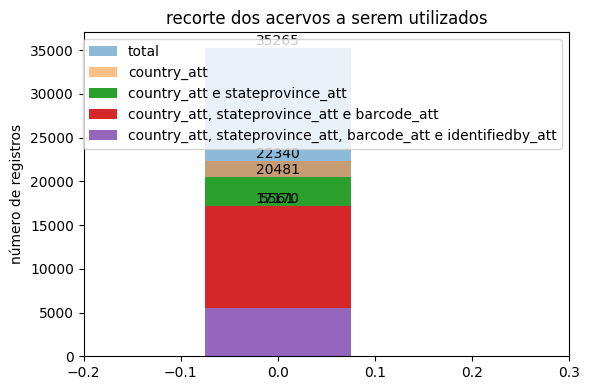

In [11]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_country],
    alpha=0.5,
    width=0.15,
    label='country_att'
)

plt.bar(
    x,
    [registros_country_state],
    width=0.15,
    label='country_att e stateprovince_att'
)

plt.bar(
    x,
    [registros_country_state_barcode],
    width=0.15,
    label='country_att, stateprovince_att e barcode_att'
)

plt.bar(
    x,
    [registros_country_state_barcode_e_identificador],
    width=0.15,
    label='country_att, stateprovince_att, barcode_att e identifiedby_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_country, str(registros_country), ha='center', va='bottom')
plt.text(0, registros_country_state, str(registros_country_state), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode_e_identificador), ha='center', va='bottom')

plt.tight_layout()
plt.show()